## Notebook com limpezas e manipulação de dados para o Questionário 1

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
# carregamento do csv da iris com erros
data = pd.read_csv('../data/iris-with-errors.csv')
print(f"número de linhas e de colunas {data.shape}")
data.head(10)

número de linhas e de colunas (25, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,duplicada
1,5.1,3.5,1.4,0.2,duplicada
2,?,3,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,5.1,3.5,1.4,0.2,duplicada
5,NaN,3.1,1.5,0.2,setosa
6,5,3.6,1.4,0.2,setosa
7,5.4,3.9,1.7,0.4,duplicada
8,5.4,3.9,1.7,0.4,duplicada
9,4.6,3.4,1.4,NaN,setosa


### Limpeza com apagamento das linhas com falta de valores

In [19]:
data_sem_nan = data.replace('?', np.nan) # substitui valores '?' por NaN
data_sem_nan = data_sem_nan.dropna() # dropa valores NaN
print(f"número de linhas e de colunas {data_sem_nan.shape}")

número de linhas e de colunas (19, 5)


In [20]:
data_sem_duplicate = data_sem_nan.drop_duplicates() # dropa duplicates
print(f"número de linhas e de colunas {data_sem_duplicate.shape}")

número de linhas e de colunas (14, 5)


### Limpeza com substituição dos valores faltantes pela média

In [21]:
data_faltante_como_media = data.replace('?', np.nan) # substitui valores '?' por NaN
data_faltante_como_media.head(25)
cols_numericas = []

# pega as colunas numéricas
for col in data_faltante_como_media.columns:
    if col != 'species':
        cols_numericas.append(col)

# calcula a média de cada uma das colunas numéricas (convertidas para float)
media_colunas = np.nanmean(np.array(data_faltante_como_media[cols_numericas], dtype=float), axis=0) 

# substitui os valores NaN pela média da coluna
for col in cols_numericas:
    data_faltante_como_media[col] = data_faltante_como_media[col].fillna(media_colunas[cols_numericas.index(col)])

# dropa duplicatas
data_faltante_como_media = data_faltante_como_media.drop_duplicates()

data_faltante_como_media.head(10)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,duplicada
2,5.022727,3,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
5,5.022727,3.1,1.5,0.2,setosa
6,5,3.6,1.4,0.2,setosa
7,5.4,3.9,1.7,0.4,duplicada
9,4.6,3.4,1.4,0.226087,setosa
10,5,3.4,1.5,0.2,setosa
11,4.4,2.9,1.4,0.2,duplicada
12,4.9,3.1,1.5,0.1,setosa


In [22]:
# para responder uma das perguntas do questionário, precisamos das medianas das colunas preenchidas por média
mediana_colunas = np.nanmedian(np.array(data_faltante_como_media[cols_numericas], dtype=float), axis=0)
print(f"mediana das colunas numéricas: {mediana_colunas}")

mediana das colunas numéricas: [5.02272727 3.41875    1.4        0.2       ]


### Boxplot para verificação de outliers

número de linhas e de colunas (150, 5)


<Axes: >

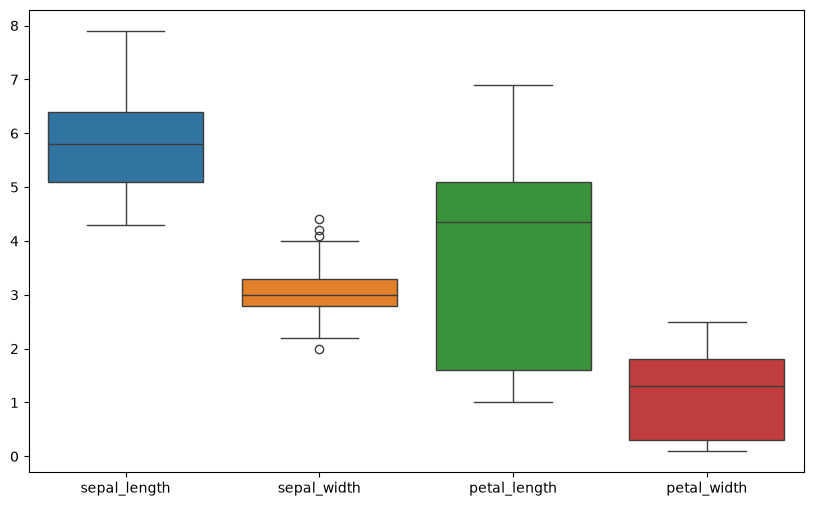

In [23]:
# carregamento do dataset da iris original
data_iris = pd.read_csv('../data/iris.csv')
print(f"número de linhas e de colunas {data_iris.shape}")
data_iris.head(10)

# plot do boxplot para análise de outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=data_iris[cols_numericas])

# obs.: não consigo encontrar mais outliers fora da coluna sepal_width. 
# a resposta certa do questionário aponta que existem outliers em todas as colunas, mas não consigo chegar a essa conclusão de jeito algum

### Análise de correlação da tabela "Advertising.csv"

In [24]:
data_adv = pd.read_csv('../data/Advertising.csv')
data_adv.head(10)

# análise de correlação entre as variáveis do dataset Advertising
correlation_matrix = data_adv.corr()
correlation_matrix

,Unnamed: 0,TV,radio,newspaper,sales
Unnamed: 0,1.000000,0.017715,-0.110680,-0.154944,-0.051616
TV,0.017715,1.000000,0.054809,0.056648,0.782224
radio,-0.110680,0.054809,1.000000,0.354104,0.576223
newspaper,-0.154944,0.056648,0.354104,1.000000,0.228299
sales,-0.051616,0.782224,0.576223,0.228299,1.000000
